# **Implementación de modelos**

## **Librerías y módulos necesarios**

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score


2025-11-07 12:20:18.290041: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-07 12:20:18.408537: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-07 12:20:19.768281: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## **Cargue de imágenes**

In [2]:
# --- PARÁMETROS ---
carpeta_espectrogramas = 'espectrogramas_mel_final_TOP10'
IMG_SIZE = 128
MAX_SAMPLES_PER_CLASS = 630
EPOCHS = 50
BATCH_SIZE = 32

In [3]:
X, y = [], []
class_names = sorted({f.split('_')[0] for f in os.listdir(carpeta_espectrogramas) if f.endswith('.png')})
class_to_index = {name: idx for idx, name in enumerate(class_names)}

for f in os.listdir(carpeta_espectrogramas):
    if not f.endswith('.png'):
        continue
    ruta = os.path.join(carpeta_espectrogramas, f)
    class_name = f.split('_')[0]  
    idx = class_to_index[class_name]
    
    try:
        img = Image.open(ruta).convert('RGB')
        img = img.resize((IMG_SIZE, IMG_SIZE))
        X.append(np.array(img))
        y.append(idx)
    except Exception as e:
        print(f"⚠️ No se pudo cargar {f}: {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)
print(f"Total imágenes cargadas: {len(y)}")
print(f"Clases encontradas: {class_names}")


⚠️ No se pudo cargar Rupornis_magnirostris_iNat577228_segment0.png: cannot identify image file 'espectrogramas_mel_final_TOP10/Rupornis_magnirostris_iNat577228_segment0.png'
⚠️ No se pudo cargar Rupornis_magnirostris_iNat801099_segment0.png: cannot identify image file 'espectrogramas_mel_final_TOP10/Rupornis_magnirostris_iNat801099_segment0.png'
⚠️ No se pudo cargar Rupornis_magnirostris_iNat786932_segment0.png: cannot identify image file 'espectrogramas_mel_final_TOP10/Rupornis_magnirostris_iNat786932_segment0.png'
⚠️ No se pudo cargar Rupornis_magnirostris_iNat358126_segment0.png: cannot identify image file 'espectrogramas_mel_final_TOP10/Rupornis_magnirostris_iNat358126_segment0.png'
⚠️ No se pudo cargar Rupornis_magnirostris_iNat42251_segment0.png: cannot identify image file 'espectrogramas_mel_final_TOP10/Rupornis_magnirostris_iNat42251_segment0.png'
⚠️ No se pudo cargar Rupornis_magnirostris_iNat801129_segment0.png: cannot identify image file 'espectrogramas_mel_final_TOP10/Rupor

## **Funciones necesarias**

In [4]:
# --- SUBSAMPLING POR CLASE ---
def subsample_classes(X, y, max_samples=MAX_SAMPLES_PER_CLASS):
    X_new, y_new = [], []
    classes = np.unique(y)
    for c in classes:
        idx = np.where(y == c)[0]
        if len(idx) > max_samples:
            idx = np.random.choice(idx, max_samples, replace=False)
        X_new.append(X[idx])
        y_new.append(y[idx])
    X_new = np.concatenate(X_new, axis=0)
    y_new = np.concatenate(y_new, axis=0)
    # Mezclar
    p = np.random.permutation(len(y_new))
    return X_new[p], y_new[p]

X, y = subsample_classes(X, y, MAX_SAMPLES_PER_CLASS)
print(f"Total después de subsampling: {len(y)}")

Total después de subsampling: 5970


In [5]:
# --- DIVISIÓN EN TRAIN / VALIDACIÓN / TEST ---
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, stratify=y_train_val, random_state=42
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# --- CREAR DATASETS DE TF ---
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

validation_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Train: 4835, Val: 538, Test: 597


I0000 00:00:1762536036.213441   27219 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9129 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:01:00.0, compute capability: 12.0


In [6]:
def generar_reporte_clasificacion(model, dataset, class_names, model_name):
    """
    Args:
        model: El modelo de Keras entrenado que se va a evaluar.
        dataset: El dataset de validación o prueba (tf.data.Dataset).
        class_names (list): Lista de los nombres de las clases.
        model_name (str): Nombre del modelo para los títulos del reporte.
    """
    # 1. Obtener predicciones y etiquetas reales de todo el dataset
    print(f"Generando predicciones para el modelo: {model_name}...")
    y_true = []
    y_pred_probs = []

    for images, labels in dataset:
        batch_pred_probs = model.predict(images, verbose=0)
        y_pred_probs.extend(batch_pred_probs)
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    # 2. Generar y mostrar el reporte
    print("\n" + "="*50)
    print(f"  Reporte de Clasificación para el Modelo: {model_name}")
    print("="*50)
    
    report = classification_report(y_true, y_pred_classes, target_names=class_names)
    print(report)

    try:
        auc_score = roc_auc_score(y_true, y_pred_probs, multi_class='ovr')
        print("\n" + "-"*50)
        print(f"AUC Score (One-vs-Rest): {auc_score:.4f}")
        print("-"*50)
    except ValueError as e:
        print(f"\nNo se pudo calcular el AUC Score: {e}")

In [7]:
def visualizar_predicciones(model, dataset, class_names, model_name):
    """
    Args:
        model: El modelo de Keras entrenado.
        dataset: El dataset de validación o prueba (tf.data.Dataset).
        class_names (list): Lista de los nombres de las clases.
        model_name (str): Título principal para la figura.
    """
    print(f"\nMostrando ejemplos de predicciones para: {model_name}...")
    plt.figure(figsize=(12, 12))
    plt.suptitle(model_name, fontsize=16)
    
    for images, labels in dataset.take(1):
        predictions = model.predict(images, verbose=0)
        
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            
            predicted_class_index = np.argmax(predictions[i])
            predicted_class_name = class_names[predicted_class_index]
            true_class_name = class_names[labels[i]]
            
            title_color = "green" if predicted_class_name == true_class_name else "red"
            plt.title(f"Predicción: {predicted_class_name}\nReal: {true_class_name}", color=title_color)
            plt.axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.97]) 
    plt.show()

In [8]:
import tensorflow as tf

class F1Macro(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='f1_macro', **kwargs):
        super(F1Macro, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.epsilon = 1e-7
        # Contadores para true positives, false positives y false negatives
        self.tp = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.fp = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.fn = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_labels = tf.argmax(y_pred, axis=1)
        y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), self.num_classes)
        y_pred_one_hot = tf.one_hot(y_pred_labels, self.num_classes)

        tp = tf.reduce_sum(y_true_one_hot * y_pred_one_hot, axis=0)
        fp = tf.reduce_sum((1 - y_true_one_hot) * y_pred_one_hot, axis=0)
        fn = tf.reduce_sum(y_true_one_hot * (1 - y_pred_one_hot), axis=0)

        self.tp.assign_add(tp)
        self.fp.assign_add(fp)
        self.fn.assign_add(fn)

    def result(self):
        precision = self.tp / (self.tp + self.fp + self.epsilon)
        recall = self.tp / (self.tp + self.fn + self.epsilon)
        f1 = 2 * precision * recall / (precision + recall + self.epsilon)
        return tf.reduce_mean(f1)  # macro: promedio de todas las clases

    def reset_states(self):
        for v in self.variables:
            v.assign(tf.zeros_like(v))


## **Modelos**

### **CNN**

In [13]:
# --- DEFINICIÓN DEL MODELO CNN ---
input_shape = (IMG_SIZE, IMG_SIZE, 3)
num_classes = len(class_names)

data_augmentation = models.Sequential([
    layers.RandomRotation(0.02),
    layers.RandomZoom(0.05),
    layers.GaussianNoise(0.015),
    layers.RandomContrast(0.15),
], name="data_augmentation_audio")

cnn_model = models.Sequential([
    layers.Input(shape=input_shape),
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

f1_macro = F1Macro(num_classes=num_classes)

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=[f1_macro])

cnn_model.summary()

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation_audio         │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# --- ENTRENAMIENTO ---
history_cnn = cnn_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping_callback]
)


Epoch 1/50


I0000 00:00:1762536186.167186   27350 cuda_dnn.cc:530] Loaded cuDNN version 90800


152/152 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - f1_macro: 0.2929 - loss: 1.9407 - val_f1_macro: 0.4669 - val_loss: 1.4614
Epoch 2/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - f1_macro: 0.4593 - loss: 1.4852 - val_f1_macro: 0.5241 - val_loss: 1.3032
Epoch 3/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - f1_macro: 0.5236 - loss: 1.3153 - val_f1_macro: 0.5403 - val_loss: 1.1870
Epoch 4/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - f1_macro: 0.5637 - loss: 1.2052 - val_f1_macro: 0.5672 - val_loss: 1.1571
Epoch 5/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - f1_macro: 0.5955 - loss: 1.1316 - val_f1_macro: 0.6136 - val_loss: 1.0742
Epoch 6/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - f1_macro: 0.6315 - loss: 1.0635 - val_f1_macro: 0.6080 - val_loss: 1.0800
Epoch 7/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - f1_macro: 0.6487 - loss: 0.9756 - val_f1_macro: 0.6491 - val_loss: 1.0323
Epoch 8/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - f1_macro: 0.6842 - loss: 0.8998 - val_f1_macro: 0.640

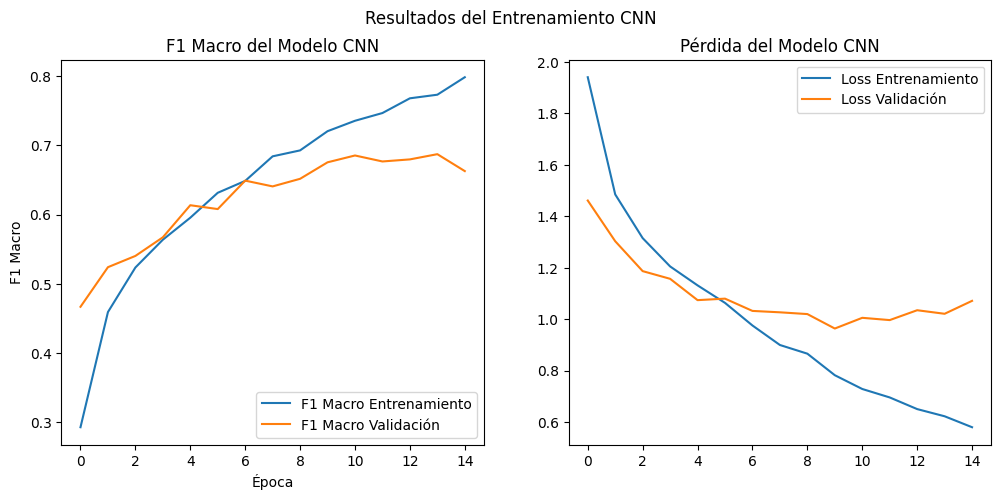

In [16]:
# --- VISUALIZACIÓN DE RESULTADOS ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['f1_macro'], label='F1 Macro Entrenamiento')
plt.plot(history_cnn.history['val_f1_macro'], label='F1 Macro Validación')
plt.legend(loc='lower right')
plt.title('F1 Macro del Modelo CNN')
plt.xlabel('Época')
plt.ylabel('F1 Macro')

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Loss Entrenamiento')
plt.plot(history_cnn.history['val_loss'], label='Loss Validación')
plt.legend(loc='upper right')
plt.title('Pérdida del Modelo CNN')
plt.suptitle('Resultados del Entrenamiento CNN')
plt.show()

In [18]:
# --- EVALUACIÓN EN TEST ---
print("\nEvaluando CNN en el conjunto de test...")
test_results = cnn_model.evaluate(test_dataset)
print(f"F1 Macro en test: {test_results[1]*100:.2f}%")


Evaluando CNN en el conjunto de test...
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - f1_macro: 0.6639 - loss: 0.9321
F1 Macro en test: 66.39%



Mostrando ejemplos de predicciones para: Predicciones CNN...


2025-11-07 12:24:35.469575: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


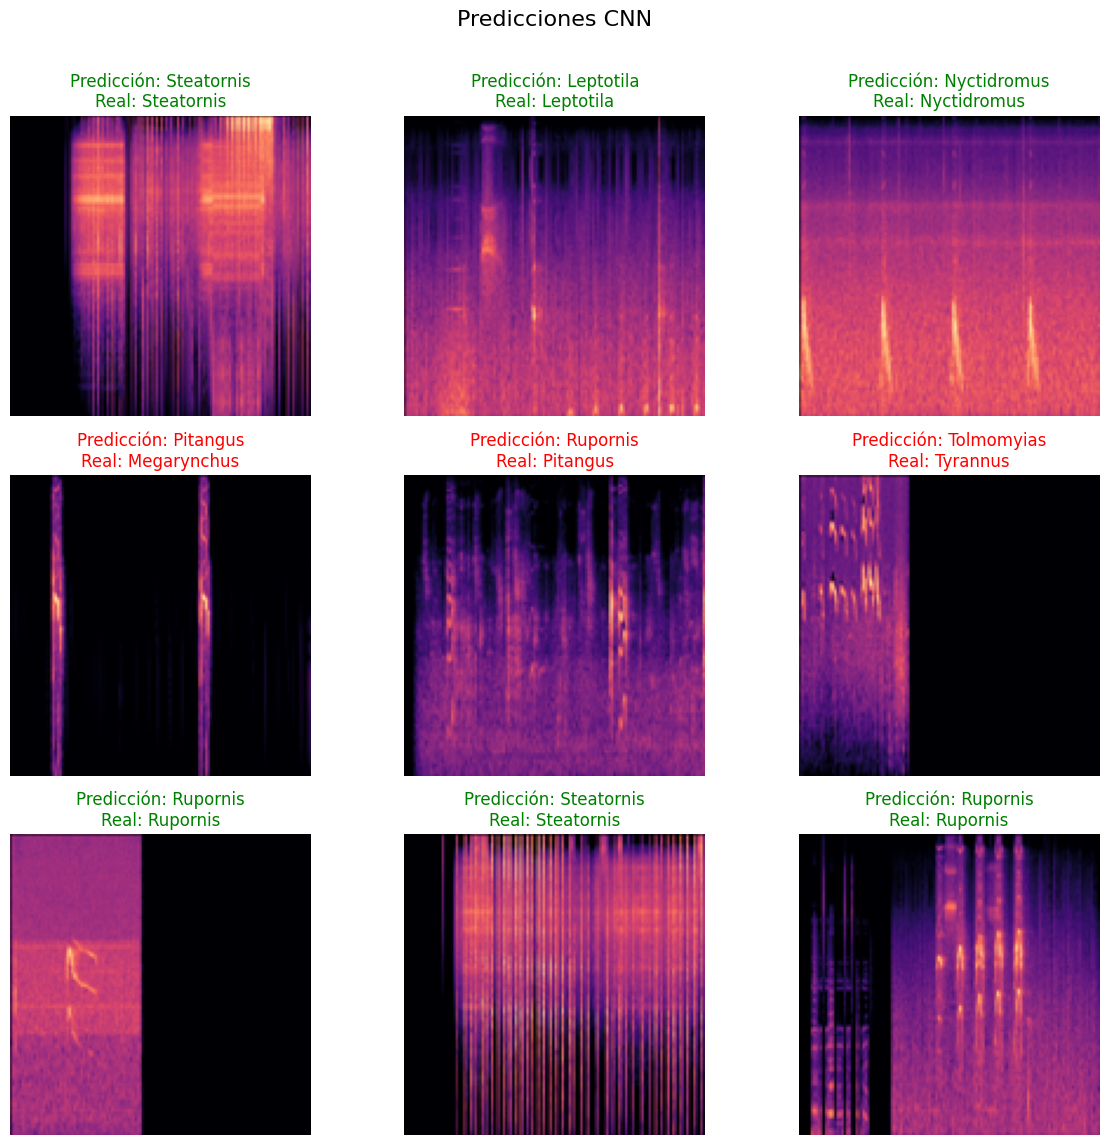

Generando predicciones para el modelo: CNN Personalizada...

  Reporte de Clasificación para el Modelo: CNN Personalizada
              precision    recall  f1-score   support

     Coereba       0.88      0.80      0.84        56
   Leptotila       0.41      0.55      0.47        53
 Megarynchus       0.69      0.53      0.60        47
 Myiozetetes       0.49      0.45      0.47        49
 Nyctidromus       0.78      0.74      0.76        57
    Pitangus       0.55      0.60      0.57        57
    Rupornis       0.76      0.67      0.71        57
  Steatornis       0.97      1.00      0.98        57
  Tolmomyias       0.65      0.67      0.66        48
    Tyrannus       0.67      0.72      0.69        57

    accuracy                           0.68       538
   macro avg       0.69      0.67      0.68       538
weighted avg       0.69      0.68      0.68       538


--------------------------------------------------
AUC Score (One-vs-Rest): 0.9386
-----------------------------------

2025-11-07 12:24:36.379431: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [19]:
# --- VISUALIZACIÓN Y REPORTE ---
visualizar_predicciones(cnn_model, validation_dataset, class_names, "Predicciones CNN")
generar_reporte_clasificacion(cnn_model, validation_dataset, class_names, "CNN Personalizada")


### **Resnet50**

In [20]:
from tensorflow.keras.applications import ResNet50

In [21]:
# ---  DEFINICIÓN DEL MODELO RESNET50 ---
print("\nConstruyendo el modelo con ResNet50...")
input_shape = (IMG_SIZE, IMG_SIZE, 3)

data_augmentation = models.Sequential([
    layers.RandomRotation(0.02),
    layers.RandomZoom(0.05),
    layers.GaussianNoise(stddev=0.015),
    layers.RandomContrast(0.15),
], name="data_augmentation_audio")

base_model_rn = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
base_model_rn.trainable = False

inputs = layers.Input(shape=input_shape)
x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model_rn(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)


f1_macro = F1Macro(num_classes=10)

model_rn = models.Model(inputs, outputs)
model_rn.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=[f1_macro])
model_rn.summary()

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)



Construyendo el modelo con ResNet50...


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation_… │ (None, 128, 128,  │          0 │ input_layer_7[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 128, 128)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 128, 128)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 128, 128)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 128, 128,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 10)        │     20,490 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [22]:
# ---  ENTRENAMIENTO DEL MODELO ---
print("\n--- Iniciando el entrenamiento de ResNet50 ---")
history_rn = model_rn.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping_callback]
)
print("--- Entrenamiento finalizado ---")



--- Iniciando el entrenamiento de ResNet50 ---
Epoch 1/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - f1_macro: 0.2854 - loss: 2.3804 - val_f1_macro: 0.3733 - val_loss: 1.7625
Epoch 2/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - f1_macro: 0.4042 - loss: 1.7871 - val_f1_macro: 0.4040 - val_loss: 1.6617
Epoch 3/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - f1_macro: 0.4475 - loss: 1.6065 - val_f1_macro: 0.4312 - val_loss: 1.5195
Epoch 4/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - f1_macro: 0.4797 - loss: 1.5052 - val_f1_macro: 0.4133 - val_loss: 1.5945
Epoch 5/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - f1_macro: 0.4985 - loss: 1.4533 - val_f1_macro: 0.4850 - val_loss: 1.5336
Epoch 6/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - f1_macro: 0.5243 - loss: 1.3693 - val_f1_macro: 0.4554 - val_loss: 1.5844
Epoch 7/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - f1_macro: 0.5343 - loss: 1.3566 - val_f1_macro: 0.4771 - val_loss: 1.4978
Epoch 8/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/s

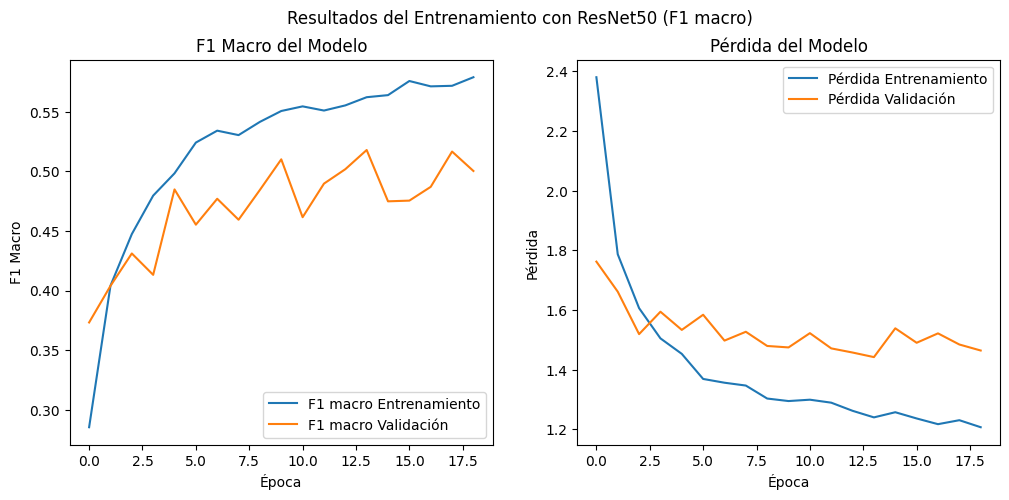


F1 macro final en validación (mejor época): 0.5180


In [23]:
# --- VISUALIZACIÓN DE RESULTADOS (F1 macro) ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_rn.history['f1_macro'], label='F1 macro Entrenamiento')
plt.plot(history_rn.history['val_f1_macro'], label='F1 macro Validación')
plt.legend(loc='lower right')
plt.title('F1 Macro del Modelo')
plt.xlabel('Época')
plt.ylabel('F1 Macro')

plt.subplot(1, 2, 2)
plt.plot(history_rn.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history_rn.history['val_loss'], label='Pérdida Validación')
plt.legend(loc='upper right')
plt.title('Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')

plt.suptitle('Resultados del Entrenamiento con ResNet50 (F1 macro)')
plt.show()

print(f"\nF1 macro final en validación (mejor época): {np.max(history_rn.history['val_f1_macro']):.4f}")



In [24]:
# --- Evaluación en el conjunto de test ---
print("\nEvaluando ResNet50 en el conjunto de test...")
test_loss, test_acc = model_rn.evaluate(test_dataset)
print(f"\nPrecisión en test: {test_acc*100:.2f}%")




Evaluando ResNet50 en el conjunto de test...
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - f1_macro: 0.5569 - loss: 1.2812

Precisión en test: 55.69%


Generando predicciones para el modelo: ResNet50 Test...

  Reporte de Clasificación para el Modelo: ResNet50 Test
              precision    recall  f1-score   support

     Coereba       0.70      0.67      0.68        63
   Leptotila       0.35      0.75      0.48        59
 Megarynchus       0.62      0.38      0.48        52
 Myiozetetes       0.47      0.33      0.39        55
 Nyctidromus       0.67      0.56      0.61        63
    Pitangus       0.50      0.41      0.45        63
    Rupornis       0.60      0.63      0.62        63
  Steatornis       0.93      1.00      0.96        63
  Tolmomyias       0.47      0.40      0.43        53
    Tyrannus       0.49      0.46      0.48        63

    accuracy                           0.57       597
   macro avg       0.58      0.56      0.56       597
weighted avg       0.58      0.57      0.56       597


--------------------------------------------------
AUC Score (One-vs-Rest): 0.8975
-------------------------------------------

2025-11-07 12:27:08.156788: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


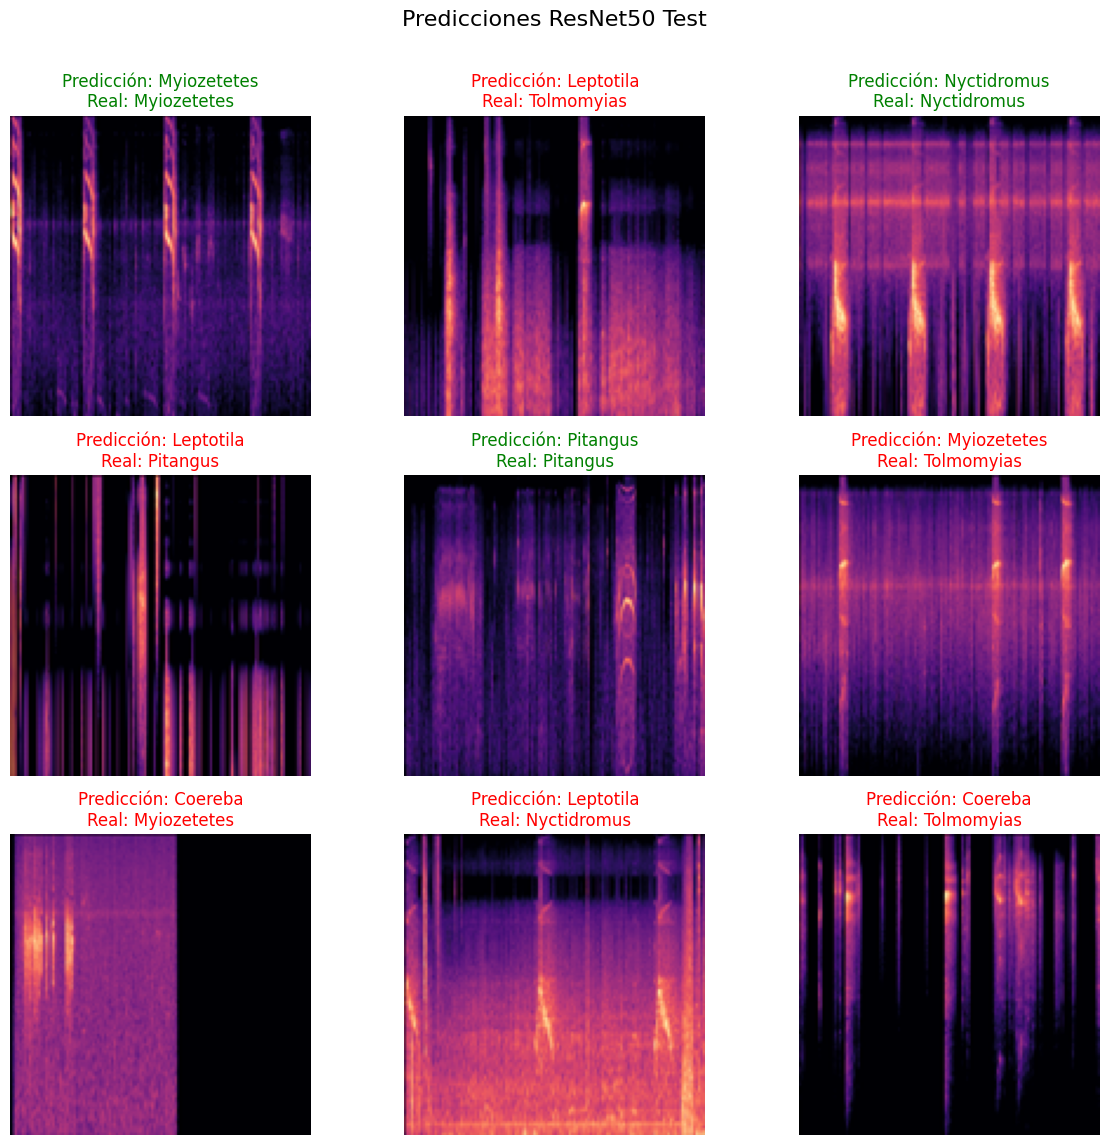

In [25]:
# --- Generar reporte completo en test ---
generar_reporte_clasificacion(model_rn, test_dataset, class_names, "ResNet50 Test")

# --- Visualizar algunas predicciones en test ---
visualizar_predicciones(model_rn, test_dataset, class_names, "Predicciones ResNet50 Test")

### **EfficientNetB0**

In [26]:
from tensorflow.keras.applications import EfficientNetB0

In [27]:
# --- DEFINICIÓN DEL MODELO CON TRANSFER LEARNING (EfficientNetB0) ---
print("\nConstruyendo el modelo con EfficientNetB0...")
input_shape = (IMG_SIZE, IMG_SIZE, 3)

data_augmentation = models.Sequential([
    layers.RandomRotation(0.02),
    layers.RandomZoom(0.05),
    layers.GaussianNoise(stddev=0.015),
    layers.RandomContrast(0.15),
], name="data_augmentation_audio")

base_model_en = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=input_shape
)
base_model_en.trainable = False  # fase 1

inputs = layers.Input(shape=input_shape)
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model_en(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model_en = models.Model(inputs, outputs)



Construyendo el modelo con EfficientNetB0...


In [28]:
# --- Compilación fase 1 ---
model_en.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=[F1Macro(num_classes)]
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


In [29]:
# --- ENTRENAMIENTO FASE 1 (cabeza congelada) ---
print("\n---  Entrenamiento fase 1 (cabeza congelada) ---")
history_en = model_en.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping_callback]
)
print("--- Fase 1 finalizada ---")


---  Entrenamiento fase 1 (cabeza congelada) ---
Epoch 1/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - f1_macro: 0.2439 - loss: 2.0639 - val_f1_macro: 0.2911 - val_loss: 1.8433
Epoch 2/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - f1_macro: 0.3434 - loss: 1.8099 - val_f1_macro: 0.3542 - val_loss: 1.7306
Epoch 3/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - f1_macro: 0.3909 - loss: 1.7168 - val_f1_macro: 0.4483 - val_loss: 1.6371
Epoch 4/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - f1_macro: 0.4067 - loss: 1.6516 - val_f1_macro: 0.4188 - val_loss: 1.6225
Epoch 5/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - f1_macro: 0.4279 - loss: 1.6096 - val_f1_macro: 0.4344 - val_loss: 1.5760
Epoch 6/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - f1_macro: 0.4443 - loss: 1.5779 - val_f1_macro: 0.4519 - val_loss: 1.5510
Epoch 7/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - f1_macro: 0.4520 - loss: 1.5530 - val_f1_macro: 0.4387 - val_loss: 1.5314
Epoch 8/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms

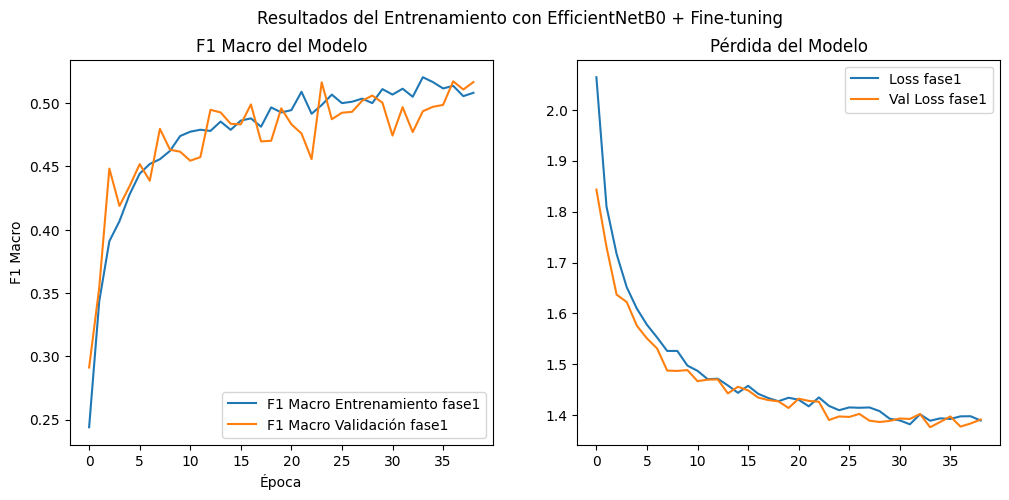

In [30]:
# --- VISUALIZACIÓN DE RESULTADOS ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_en.history['f1_macro'], label='F1 Macro Entrenamiento fase1')
plt.plot(history_en.history['val_f1_macro'], label='F1 Macro Validación fase1')

plt.legend(loc='lower right')
plt.title('F1 Macro del Modelo')
plt.xlabel('Época')
plt.ylabel('F1 Macro')

plt.subplot(1, 2, 2)
plt.plot(history_en.history['loss'], label='Loss fase1')
plt.plot(history_en.history['val_loss'], label='Val Loss fase1')
plt.legend(loc='upper right')
plt.title('Pérdida del Modelo')
plt.suptitle('Resultados del Entrenamiento con EfficientNetB0 + Fine-tuning')
plt.show()


Evaluando EfficientNetB0 en el conjunto de test...
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - f1_macro: 0.5233 - loss: 1.3607
F1 Macro en test: 52.33%

Mostrando ejemplos de predicciones para: Predicciones EfficientNetB0 Test...


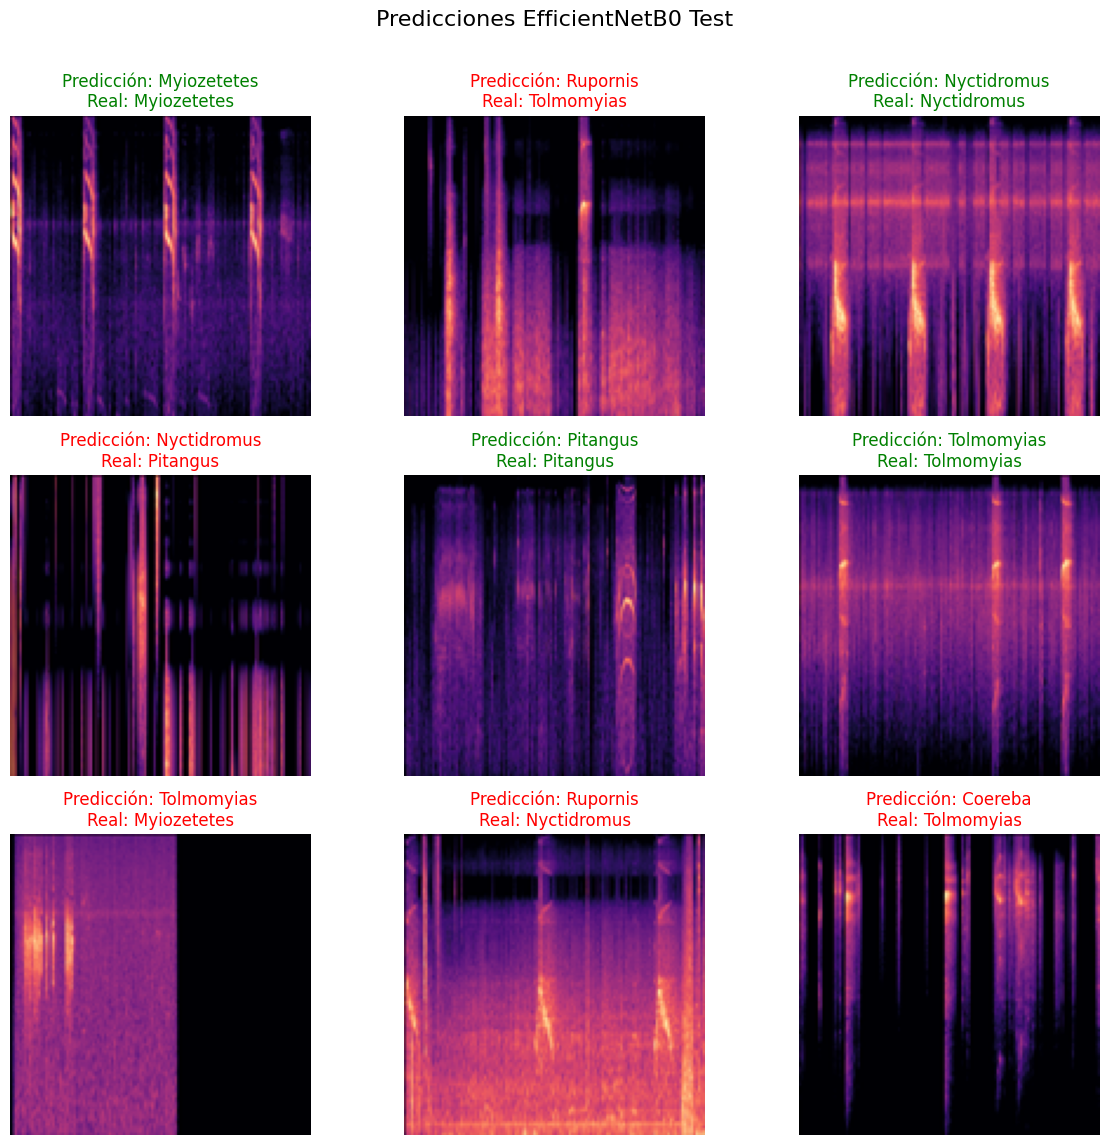

Generando predicciones para el modelo: EfficientNetB0 Test...

  Reporte de Clasificación para el Modelo: EfficientNetB0 Test
              precision    recall  f1-score   support

     Coereba       0.56      0.60      0.58        63
   Leptotila       0.43      0.63      0.51        59
 Megarynchus       0.54      0.27      0.36        52
 Myiozetetes       0.50      0.31      0.38        55
 Nyctidromus       0.63      0.62      0.62        63
    Pitangus       0.43      0.35      0.39        63
    Rupornis       0.50      0.63      0.56        63
  Steatornis       0.94      0.98      0.96        63
  Tolmomyias       0.41      0.38      0.39        53
    Tyrannus       0.45      0.52      0.48        63

    accuracy                           0.54       597
   macro avg       0.54      0.53      0.52       597
weighted avg       0.54      0.54      0.53       597


--------------------------------------------------
AUC Score (One-vs-Rest): 0.8792
-------------------------------

In [31]:
# --- EVALUACIÓN EN TEST ---
print("\nEvaluando EfficientNetB0 en el conjunto de test...")
test_results = model_en.evaluate(test_dataset)
print(f"F1 Macro en test: {test_results[1]*100:.2f}%")

# --- PREDICCIONES Y REPORTE ---
visualizar_predicciones(model_en, test_dataset, class_names, "Predicciones EfficientNetB0 Test")
generar_reporte_clasificacion(model_en, test_dataset, class_names, "EfficientNetB0 Test")

## **Comparación de Modelos Benchmark y Conclusiones**

Se evaluaron tres modelos benchmark para la clasificación de espectrogramas de aves: **CNN Personalizada**, **ResNet50** y **EfficientNetB0**. Los resultados permiten establecer un punto de referencia antes de implementar optimizaciones avanzadas.

| Modelo            | F1 Macro (%) | Accuracy (%) | AUC (One-vs-Rest) |
| ----------------- | ------------ | ------------ | ----------------- |
| CNN Personalizada | 68           | 68           | 93.86             |
| ResNet50          | 56           | 57           | 89.75             |
| EfficientNetB0    | 52           | 54           | 87.92             |

### **Observaciones**

* La **CNN Personalizada** obtuvo el mejor desempeño global, equilibrando precisión y recall en la mayoría de las clases.
* Los modelos preentrenados (**ResNet50** y **EfficientNetB0**) no superaron a la CNN en este dataset, probablemente por el tamaño limitado de los datos y la diferencia entre imágenes de ImageNet y espectrogramas de audio.
* La diferencia entre **accuracy** y **F1 macro** muestra que algunas clases minoritarias tienen menor representación, confirmando que el **F1 macro** es la métrica más relevante para este benchmark.

### **Conclusión**

* Estos modelos sirven como **referencia inicial (benchmark)** para la tarea de clasificación de espectrogramas.
* La **CNN Personalizada** se perfila como la mejor opción de partida.
* Futuras mejoras podrían explorarse mediante **fine-tuning de modelos preentrenados**, **aumento de datos específico para audio** y **estrategias de balance de clases**, usando siempre el **F1 macro** como métrica guía.

